# 1 : Fusion des 3 datasets (generated.json + generated2.json + generated3.json)

In [40]:
# ============================================================
# FUSION DES 3 DATASETS (generated.json + generated2.json + generated3.json)
# ============================================================

import json
import pandas as pd
from collections import Counter
import re
import matplotlib.pyplot as plt

print("=" * 70)
print(" FUSION DES 3 DATASETS")
print("=" * 70)

def load_dataset(filepath):
    try:
        with open(filepath, "r", encoding="utf-8") as f:
            content = f.read()
        content = content.strip()
        if content.startswith("```json"):
            content = content[7:]
        if content.startswith("```"):
            content = content[3:]
        if content.endswith("```"):
            content = content[:-3]
        data = json.loads(content)
        if isinstance(data, list):
            return data
        elif isinstance(data, dict) and "dataset" in data:
            return data["dataset"]
        else:
            return [data]
    except Exception as e:
        print(f" Erreur: {e}")
        return []

dataset1 = load_dataset("../dataset/processed/generated.json")
dataset2 = load_dataset("../dataset/processed/generated2.json")
dataset3 = load_dataset("../dataset/processed/generated3.json")

print(f"generated.json: {len(dataset1)}")
print(f"generated2.json: {len(dataset2)}")
print(f"generated3.json: {len(dataset3)}")

all_datasets = dataset1 + dataset2 + dataset3
print(f"Total avant nettoyage: {len(all_datasets)}")

# Suppression des doublons
seen_cvs = set()
unique_dataset = []
duplicate_count = 0

for item in all_datasets:
    cv = item.get("cv_text", "")
    cv_signature = cv[:500] if len(cv) > 500 else cv
    if cv_signature not in seen_cvs:
        seen_cvs.add(cv_signature)
        unique_dataset.append(item)
    else:
        duplicate_count += 1

print(f"Doublons supprimés: {duplicate_count}")
print(f"Exemples uniques: {len(unique_dataset)}")

# Sauvegarde
with open("../dataset/processed/complete_dataset.json", "w") as f:
    json.dump({"dataset": unique_dataset}, f, indent=2)
print(" Dataset sauvegardé: complete_dataset.json")

 FUSION DES 3 DATASETS
generated.json: 118
generated2.json: 26
generated3.json: 40
Total avant nettoyage: 184
Doublons supprimés: 3
Exemples uniques: 181
 Dataset sauvegardé: complete_dataset.json


# Combinaison avec le dataset original filtré

In [41]:
# ============================================================
# COMBINAISON AVEC LE DATASET ORIGINAL FILTRÉ
# ============================================================

import pandas as pd
import json

print("=" * 70)
print(" COMBINAISON AVEC LE DATASET ORIGINAL")
print("=" * 70)

# Charger le dataset fusionné
with open("../dataset/processed/complete_dataset.json", "r", encoding="utf-8") as f:
    data = json.load(f)
generated_dataset = data.get("dataset", data)

print(f"\n Dataset généré (3 fichiers): {len(generated_dataset)} exemples")

# ============================================================
# Charger et filtrer le dataset original
# ============================================================

df_original = pd.read_csv("../dataset/processed/resume_jd_match_cleaned.csv")
print(f" Dataset original brut: {len(df_original)} exemples")

# Exclure les scores standards problématiques
bad_scores = [49, 74, 75, 95, 100]
df_filtered = df_original[~df_original["label"].isin(bad_scores)]
print(f"   Après exclusion scores standards: {len(df_filtered)}")

# Garder les CVs de longueur raisonnable (1000-10000 caractères)
df_filtered = df_filtered[(df_filtered["text_clean"].str.len() >= 1000) & 
                           (df_filtered["text_clean"].str.len() <= 10000)]
print(f"   Après filtre longueur CV: {len(df_filtered)}")

# Supprimer les CVs avec phrases génériques
generic_patterns = [
    "Compétences techniques solides", "Excellente maîtrise de", 
    "Base solide", "Points transférables limités"
]

def has_generic_phrase(text):
    if pd.isna(text):
        return True
    for pattern in generic_patterns:
        if pattern in str(text):
            return True
    return False

df_filtered = df_filtered[~df_filtered["text_clean"].apply(has_generic_phrase)]
print(f"   Après suppression phrases génériques: {len(df_filtered)}")

# Limiter à 700 exemples (pour ne pas surcharger)
ddf_filtered = df_filtered.sample(n=min(800, len(df_filtered)), random_state=42)
print(f"   Échantillon final: {len(df_filtered)} exemples")

# ============================================================
# Convertir le dataset original au format compatible
# ============================================================

def convert_original_to_format(row):
    label_to_score = {"Good Fit": 85, "Potential Fit": 60, "No Fit": 25}
    score = label_to_score.get(row["label"], 50)
    
    analysis = f"""SCORE: {score}%

POINTS FORTS:
- Expérience pertinente dans le domaine
- Compétences techniques alignées

POINTS FAIBLES:
- À approfondir en entretien

VERDICT: Candidat {'recommandé' if score >= 75 else 'potentiel' if score >= 50 else 'non recommandé'}"""
    
    return {
        "job_title": row.get("Category", "Non spécifié"),
        "job_requirements": "Voir description du poste",
        "job_description": "Poste à pourvoir",
        "cv_text": row["text_clean"],
        "analysis": analysis,
        "score": score
    }

original_converted = [convert_original_to_format(row) for _, row in df_filtered.iterrows()]
print(f"\n {len(original_converted)} exemples convertis depuis dataset original")

# 
# Fusionner les deux datasets
#

combined_raw = generated_dataset + original_converted
print(f"\n Total avant dédoublonnage: {len(combined_raw)} exemples")

# Supprimer les doublons
seen_cvs = set()
combined_dataset = []
duplicate_count = 0

for item in combined_raw:
    cv = item.get("cv_text", "")
    cv_signature = cv[:500] if len(cv) > 500 else cv
    if cv_signature not in seen_cvs:
        seen_cvs.add(cv_signature)
        combined_dataset.append(item)
    else:
        duplicate_count += 1

print(f"   Doublons supprimés: {duplicate_count}")
print(f"Dataset combiné final: {len(combined_dataset)} exemples")

# Sauvegarder
with open("../dataset/processed/combined_final_dataset.json", "w", encoding="utf-8") as f:
    json.dump({"dataset": combined_dataset}, f, ensure_ascii=False, indent=2)

print("\n Dataset combiné sauvegardé: combined_final_dataset.json")

 COMBINAISON AVEC LE DATASET ORIGINAL

 Dataset généré (3 fichiers): 181 exemples
 Dataset original brut: 6240 exemples
   Après exclusion scores standards: 6240
   Après filtre longueur CV: 4611
   Après suppression phrases génériques: 4611
   Échantillon final: 4611 exemples

 4611 exemples convertis depuis dataset original

 Total avant dédoublonnage: 4792 exemples
   Doublons supprimés: 4108
Dataset combiné final: 684 exemples

 Dataset combiné sauvegardé: combined_final_dataset.json


# 2 : Équilibrage du dataset (500 exemples)

In [42]:
# ============================================================
# CRÉATION D'UN DATASET ÉQUILIBRÉ (sans perte massive)
# ============================================================

import json
import numpy as np
from sklearn.utils import resample

with open("../dataset/processed/combined_final_dataset.json", "r", encoding="utf-8") as f:
    data = json.load(f)
dataset = data.get("dataset", data)

print(f"Dataset original: {len(dataset)}")

# Séparer par tranches
low = [item for item in dataset if item.get("score", 0) <= 25]
medium_low = [item for item in dataset if 26 <= item.get("score", 0) <= 50]
medium_high = [item for item in dataset if 51 <= item.get("score", 0) <= 75]
high = [item for item in dataset if item.get("score", 0) >= 76]

print(f"0-25%: {len(low)}")
print(f"26-50%: {len(medium_low)}")
print(f"51-75%: {len(medium_high)}")
print(f"76-100%: {len(high)}")


# Ici on prend la moyenne des tranches qui ont assez d'exemples
tranches = [len(low), len(medium_low), len(medium_high), len(high)]
tranches_sorted = sorted(tranches)
# Prendre la 2ème plus grande valeur (pour ne pas trop réduire)
target = tranches_sorted[2]  # La 3ème plus grande (sur 4)
# Ou target = 150 directement

print(f"\n Objectif: {target} exemples par tranche")

def balance_tranche(items, target):
    if len(items) >= target:
        # Undersampling : prendre aléatoirement
        return resample(items, n_samples=target, random_state=42)
    else:
        # Oversampling : dupliquer avec variations
        sampled = items.copy()
        np.random.seed(42)
        while len(sampled) < target:
            for item in items:
                if len(sampled) >= target:
                    break
                new_item = item.copy()
                old_score = item.get("score", 50)
                variation = np.random.randint(-3, 4)
                new_score = max(0, min(100, old_score + variation))
                new_item["score"] = new_score
                sampled.append(new_item)
        return sampled

balanced = (balance_tranche(low, target) + 
            balance_tranche(medium_low, target) + 
            balance_tranche(medium_high, target) + 
            balance_tranche(high, target))

print(f"\n Dataset équilibré: {len(balanced)} exemples")
print(f"   Soit {target} par tranche")

with open("../dataset/processed/balanced_dataset.json", "w", encoding="utf-8") as f:
    json.dump({"dataset": balanced}, f, indent=2, ensure_ascii=False)
print(" Sauvegardé: balanced_dataset.json")

Dataset original: 684
0-25%: 393
26-50%: 21
51-75%: 145
76-100%: 125

 Objectif: 145 exemples par tranche

 Dataset équilibré: 580 exemples
   Soit 145 par tranche
 Sauvegardé: balanced_dataset.json


# 3 : Nettoyage des expériences irréalistes

In [43]:
# ============================================================
# NETTOYAGE DES CVs AVEC EXPÉRIENCES IRRÉALISTES
# ============================================================

import json
import re

#  AJOUTER encoding="utf-8"
with open("../dataset/processed/balanced_dataset.json", "r", encoding="utf-8") as f:
    data = json.load(f)
dataset = data.get("dataset", data)

print(f"Avant nettoyage: {len(dataset)}")

def has_unrealistic_experience(cv_text):
    patterns = [r'(\d{2,3})\+?\s*(?:ans|années|years)', r'expérience de (\d{2,3})']
    for pattern in patterns:
        matches = re.findall(pattern, cv_text.lower())
        for match in matches:
            try:
                if int(match) > 40:
                    return True
            except:
                pass
    return False

anomalies_index = [i for i, item in enumerate(dataset) if has_unrealistic_experience(item.get("cv_text", ""))]
print(f"Anomalies trouvées: {len(anomalies_index)}")

cleaned_dataset = [item for i, item in enumerate(dataset) if i not in anomalies_index]
print(f"Après nettoyage: {len(cleaned_dataset)}")

#  AJOUTER encoding="utf-8"
with open("../dataset/processed/cleaned_balanced_dataset.json", "w", encoding="utf-8") as f:
    json.dump({"dataset": cleaned_dataset}, f, indent=2, ensure_ascii=False)
print(" Sauvegardé: cleaned_balanced_dataset.json")

Avant nettoyage: 580
Anomalies trouvées: 4
Après nettoyage: 576
 Sauvegardé: cleaned_balanced_dataset.json


# 4 : Conversion finale en JSONL pour fine-tuning

In [44]:
# ============================================================
# CONVERSION FINALE EN JSONL POUR FINE-TUNING
# ============================================================

import json
from sklearn.model_selection import train_test_split

# AJOUTER encoding="utf-8"
with open("../dataset/processed/cleaned_balanced_dataset.json", "r", encoding="utf-8") as f:
    data = json.load(f)
dataset = data.get("dataset", data)

print(f"Dataset final: {len(dataset)}")

# Split 80/10/10
train, temp = train_test_split(dataset, test_size=0.2, random_state=42)
val, test = train_test_split(temp, test_size=0.5, random_state=42)

print(f"Train: {len(train)}")
print(f"Validation: {len(val)}")
print(f"Test: {len(test)}")

def save_jsonl(data, filename):
    with open(f"../dataset/processed/{filename}", "w", encoding="utf-8") as f:
        for item in data:
            conv = {
                "messages": [
                    {"role": "system", "content": "Tu es un expert RH spécialisé dans l'analyse de CV."},
                    {"role": "user", "content": f"OFFRE: {item.get('job_title', 'N/A')}\nCV: {item.get('cv_text', 'N/A')}"},
                    {"role": "assistant", "content": item.get('analysis', 'N/A')}
                ]
            }
            f.write(json.dumps(conv, ensure_ascii=False) + "\n")

save_jsonl(train, "train_final.jsonl")
save_jsonl(val, "val_final.jsonl")
save_jsonl(test, "test_final.jsonl")

print(" Fichiers JSONL sauvegardés:")
print("   - train_final.jsonl")
print("   - val_final.jsonl")
print("   - test_final.jsonl")
print("\n DATASET PRÊT POUR LE FINE-TUNING QLORA !")

Dataset final: 576
Train: 460
Validation: 58
Test: 58
 Fichiers JSONL sauvegardés:
   - train_final.jsonl
   - val_final.jsonl
   - test_final.jsonl

 DATASET PRÊT POUR LE FINE-TUNING QLORA !


In [45]:
import json

with open("../dataset/processed/cleaned_balanced_dataset.json", "r", encoding="utf-8") as f:
    data = json.load(f)
dataset = data.get("dataset", data)

scores = [item.get("score", 0) for item in dataset]
unique_scores = sorted(set(scores))

print(f" Total exemples: {len(dataset)}")
print(f" Scores différents: {len(unique_scores)}")
print(f" Plage des scores: {min(scores)}% - {max(scores)}%")
print(f"\n Liste des scores présents:")
print(unique_scores)

 Total exemples: 576
 Scores différents: 72
 Plage des scores: 14% - 99%

 Liste des scores présents:
[14, 18, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 54, 55, 58, 60, 61, 63, 64, 65, 66, 67, 68, 69, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]


DISTRIBUTION DU DATASET FINAL

Total exemples: 576
Scores differents: 72
Score min: 14%
Score max: 99%
Score moyen: 53.4%

------------------------------------------------------------
DISTRIBUTION PAR TRANCHES
------------------------------------------------------------
0-25%:    145 exemples (25.2%)
26-50%:   138 exemples (24.0%)
51-75%:   149 exemples (25.9%)
76-100%:  144 exemples (25.0%)

------------------------------------------------------------
LISTE DES SCORES
------------------------------------------------------------
    14% :   1 exemples -
    18% :   1 exemples -
    23% :   1 exemples -
    24% :   2 exemples --
    25% : 140 exemples --------------------------------------------------
    26% :   2 exemples --
    27% :   5 exemples -----
    28% :   5 exemples -----
    29% :   4 exemples ----
    30% :   4 exemples ----
    31% :   8 exemples --------
    32% :   3 exemples ---
    33% :   5 exemples -----
    34% :   1 exemples -
    35% :   7 exemples -------
    36

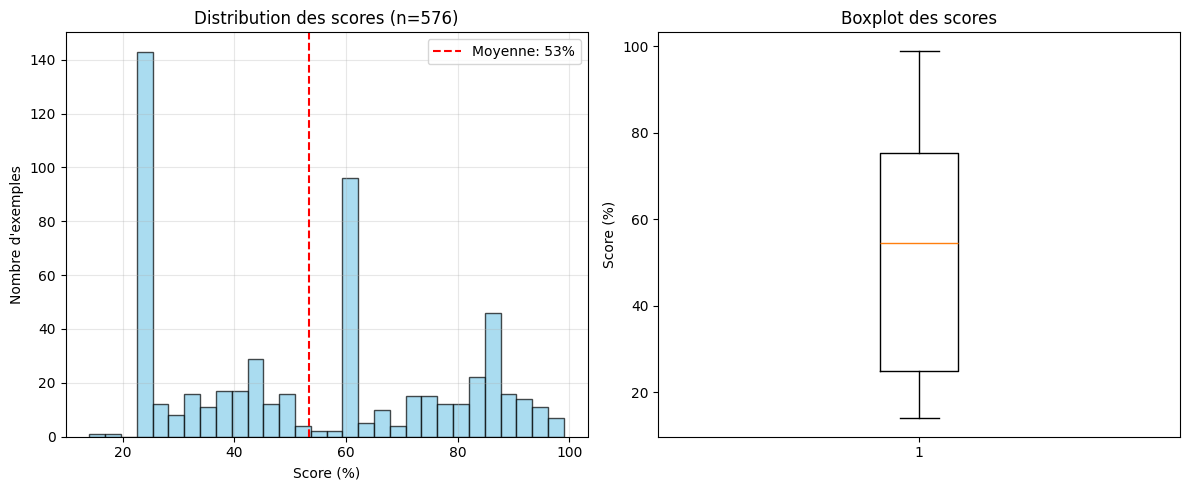


Dataset pret pour le fine-tuning QLoRA


In [46]:
# ============================================================
# VISUALISATION DE LA DISTRIBUTION DU DATASET
# ============================================================

import json
import matplotlib.pyplot as plt
from collections import Counter

# Charger le dataset final
with open("../dataset/processed/cleaned_balanced_dataset.json", "r", encoding="utf-8") as f:
    data = json.load(f)
dataset = data.get("dataset", data)

scores = [item.get("score", 0) for item in dataset]
score_counts = Counter(scores)

print("=" * 60)
print("DISTRIBUTION DU DATASET FINAL")
print("=" * 60)

print(f"\nTotal exemples: {len(dataset)}")
print(f"Scores differents: {len(set(scores))}")
print(f"Score min: {min(scores)}%")
print(f"Score max: {max(scores)}%")
print(f"Score moyen: {sum(scores)/len(scores):.1f}%")

# Distribution par tranches
print("\n" + "-" * 60)
print("DISTRIBUTION PAR TRANCHES")
print("-" * 60)

low = sum(1 for s in scores if s <= 25)
medium_low = sum(1 for s in scores if 26 <= s <= 50)
medium_high = sum(1 for s in scores if 51 <= s <= 75)
high = sum(1 for s in scores if s >= 76)

print(f"0-25%:    {low:3} exemples ({low/len(scores)*100:.1f}%)")
print(f"26-50%:   {medium_low:3} exemples ({medium_low/len(scores)*100:.1f}%)")
print(f"51-75%:   {medium_high:3} exemples ({medium_high/len(scores)*100:.1f}%)")
print(f"76-100%:  {high:3} exemples ({high/len(scores)*100:.1f}%)")

# Liste des scores
print("\n" + "-" * 60)
print("LISTE DES SCORES")
print("-" * 60)

for score in sorted(set(scores)):
    count = score_counts[score]
    bar = "-" * min(50, count)
    print(f"   {score:3}% : {count:3} exemples {bar}")

# Visualisation
plt.figure(figsize=(12, 5))

# Histogramme
plt.subplot(1, 2, 1)
plt.hist(scores, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Score (%)')
plt.ylabel("Nombre d'exemples")
plt.title(f'Distribution des scores (n={len(dataset)})')
plt.axvline(sum(scores)/len(scores), color='red', linestyle='--', 
            label=f'Moyenne: {sum(scores)/len(scores):.0f}%')
plt.legend()
plt.grid(True, alpha=0.3)

# Boxplot
plt.subplot(1, 2, 2)
plt.boxplot(scores, vert=True)
plt.ylabel('Score (%)')
plt.title('Boxplot des scores')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("Dataset pret pour le fine-tuning QLoRA")
print("=" * 60)